# HOUSE PRICE PREDICTION

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')

##Load Data

In [2]:
df = pd.read_csv('Bengaluru_House_Data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [4]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


### Drop irrelevant Columns

In [5]:
df2 = df.drop(['society', 'availability'], axis=1)
df2.shape

(13320, 7)

In [6]:
df2['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

###Extract BHK as a number

In [7]:
df2['BHK'] = df2['size'].apply(lambda x: int(str(x).split(' ')[0]) if pd.notnull(x) else np.nan)
df2[['size', 'BHK']].head(10)

,size,BHK
0,2 BHK,2.0
1,4 Bedroom,4.0
2,3 BHK,3.0
3,3 BHK,3.0
4,2 BHK,2.0
5,2 BHK,2.0
6,4 BHK,4.0
7,4 BHK,4.0
8,3 BHK,3.0
9,6 Bedroom,6.0


###Inspect total_sqft for non-standard entries

In [8]:
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

df2[~df2['total_sqft'].apply(is_float)].head(15)

,area_type,location,size,total_sqft,bath,balcony,price,BHK
30,Super built-up Area,Yelahanka,4 BHK,2100 - 2850,4.0,0.0,186.000,4.0
56,Built-up Area,Devanahalli,4 Bedroom,3010 - 3410,NaN,NaN,192.000,4.0
81,Built-up Area,Hennur Road,4 Bedroom,2957 - 3450,NaN,NaN,224.500,4.0
122,Super built-up Area,Hebbal,4 BHK,3067 - 8156,4.0,0.0,477.000,4.0
137,Super built-up Area,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,0.0,54.005,2.0
165,Super built-up Area,Sarjapur,2 BHK,1145 - 1340,2.0,0.0,43.490,2.0
188,Super built-up Area,KR Puram,2 BHK,1015 - 1540,2.0,0.0,56.800,2.0
224,Super built-up Area,Devanahalli,3 BHK,1520 - 1740,NaN,NaN,74.820,3.0
410,Super built-up Area,Kengeri,1 BHK,34.46Sq. Meter,1.0,0.0,18.500,1.0
549,Super built-up Area,Hennur Road,2 BHK,1195 - 1440,2.0,0.0,63.770,2.0


###Convert total_sqft to a clean float

In [9]:
def convert_sqft_to_num(x):
    x = str(x).strip()
    if '-' in x:
        tokens = x.split('-')
        try:
            return (float(tokens[0]) + float(tokens[1])) / 2
        except:
            return np.nan
    elif 'Sq. Meter' in x:
        try:
            return float(x.replace('Sq. Meter', '').strip()) * 10.7639
        except:
            return np.nan
    elif 'Perch' in x:
        try:
            return float(x.replace('Perch', '').strip()) * 272.25
        except:
            return np.nan
    else:
        try:
            return float(x)
        except:
            return np.nan

df2['total_sqft_clean'] = df2['total_sqft'].apply(convert_sqft_to_num)
df2[['total_sqft', 'total_sqft_clean']].isnull().sum()

,0
total_sqft,0
total_sqft_clean,28


In [10]:
df2[df2['total_sqft_clean'].isnull()][['location', 'size', 'total_sqft']]

,location,size,total_sqft
872,Singapura Village,2 BHK,1100Sq. Yards
1019,Marathi Layout,1 Bedroom,5.31Acres
1086,Narasapura,2 Bedroom,30Acres
1821,Sarjapur,3 Bedroom,1574Sq. Yards
2310,Whitefield,4 BHK,361.33Sq. Yards
2881,Volagerekallahalli,2 BHK,117Sq. Yards
3285,Whitefield,4 Bedroom,500Sq. Yards
4293,Bannerghatta Road,4 BHK,315Sq. Yards
5453,Kannur,6 Bedroom,3Cents
5537,Frazer Town,3 BHK,188.89Sq. Yards


Drop rows that failed conversion

In [11]:
df3 = df2[df2['total_sqft_clean'].notnull()].copy()
df3.drop('total_sqft', axis=1, inplace=True)
df3.rename(columns={'total_sqft_clean': 'total_sqft'}, inplace=True)
df3.shape

(13292, 8)

###Handle remaining missing values


In [12]:
df3.isnull().sum()

,0
area_type,0
location,1
size,16
bath,73
balcony,606
price,0
BHK,16
total_sqft,0


In [13]:
# Drop the 1 missing location and 16 missing BHK/size rows (negligible)
df4 = df3[df3['location'].notnull() & df3['BHK'].notnull()].copy()

# Fill bath with median (grouped by BHK makes more sense than overall median)
df4['bath'] = df4['bath'].fillna(df4.groupby('BHK')['bath'].transform('median'))

# Fill balcony with median too
df4['balcony'] = df4['balcony'].fillna(df4['balcony'].median())

df4.isnull().sum()

,0
area_type,0
location,0
size,0
bath,0
balcony,0
price,0
BHK,0
total_sqft,0


##Check for BHK vs sqft mismatch

In [14]:
df4[df4['total_sqft'] / df4['BHK'] < 300].shape[0]

745

### Remove BHK/sqft outliers

In [15]:
df5 = df4[~(df4['total_sqft'] / df4['BHK'] < 300)]
df5.shape

(12530, 8)

###Remove price-per-sqft outliers

In [17]:
df5 = df5.copy()
df5['price_per_sqft'] = (df5['price'] * 100000) / df5['total_sqft']
df5['price_per_sqft'].describe()

,price_per_sqft
count,12530.000000
mean,6304.294766
std,4160.462665
min,23.596850
25%,4210.526316
50%,5294.117647
75%,6918.981155
max,176470.588235


###Remove outliers grouped by location

In [18]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df6 = remove_pps_outliers(df5)
df6.shape

(9326, 9)

###Remove bath/BHK outliers

In [19]:
df6[df6.bath > df6.BHK + 2].shape[0]

5

In [20]:
df7 = df6[df6.bath <= (df6.BHK + 2)]
df7.shape


(9321, 9)

##Handle high-cardinality location column

In [21]:
df7 = df7.copy()
location_stats = df7['location'].apply(lambda x: x.strip()).value_counts()
location_stats_less_than_10 = location_stats[location_stats <= 10]
len(location_stats_less_than_10)

582

###Group rare locations into "other"

In [22]:
df7['location'] = df7['location'].apply(lambda x: x.strip())
df7['location'] = df7['location'].apply(lambda x: 'other' if x in location_stats_less_than_10 else x)
df7['location'].nunique()

181

###One-hot encode location and area_type

In [23]:
dummies_location = pd.get_dummies(df7['location'], drop_first=True)
dummies_area = pd.get_dummies(df7['area_type'], drop_first=True)

df8 = pd.concat([df7, dummies_location, dummies_area], axis=1)
df8 = df8.drop(['location', 'area_type', 'size', 'price_per_sqft'], axis=1)

df8.shape

(9321, 188)

###Prepare X (features) and y (target)

In [24]:
X = df8.drop('price', axis=1)
y = df8['price']

X.shape, y.shape

((9321, 187), (9321,))

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((7456, 187), (1865, 187))

###Train Linear Regression

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

R2 Score: 0.6645918592040044
MAE: 24.211238705623533
RMSE: 66.31516049305684


###Ridge Regression

In [27]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

R2 Score: 0.6647361273375437
MAE: 24.111392721858543
RMSE: 66.30089698501781


###Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R2 Score: 0.6929126369047981
MAE: 21.192696609115902
RMSE: 63.45370686809729


### XGboost

In [29]:
!pip install xgboost -q

from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

R2 Score: 0.504567104405561
MAE: 22.221978622722883
RMSE: 80.59691989471696


####Retune XGBoost

In [30]:
xgb2 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb2.fit(X_train, y_train)

y_pred_xgb2 = xgb2.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_xgb2))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb2)))

R2 Score: 0.5789040012283377
MAE: 22.748019263218936
RMSE: 74.30475093257554


##Final comparison table

In [31]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Random Forest', 'XGBoost'],
    'R2 Score': [0.6646, 0.6647, 0.6929, 0.5789],
    'MAE': [24.21, 24.11, 21.19, 22.75],
    'RMSE': [66.32, 66.30, 63.45, 74.30]
})
results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.6646,24.21,66.32
1,Ridge Regression,0.6647,24.11,66.30
2,Random Forest,0.6929,21.19,63.45
3,XGBoost,0.5789,22.75,74.30


###Feature importance from Random Forest

In [32]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(15)

,0
total_sqft,0.767367
bath,0.039502
other,0.030191
balcony,0.026597
BHK,0.026121
Cunningham Road,0.021489
Super built-up Area,0.019989
Rajaji Nagar,0.015056
Plot Area,0.011803
Indira Nagar,0.007568


##Visualize — Actual vs Predicted

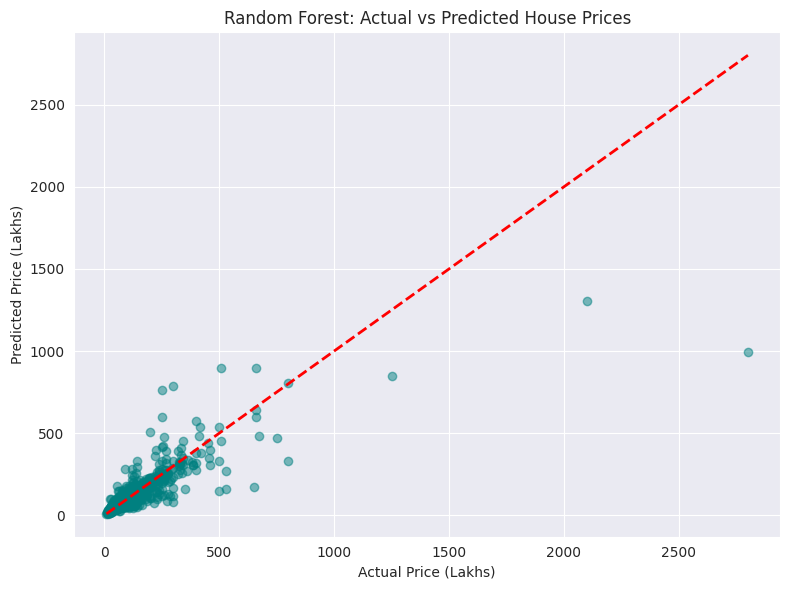

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Random Forest: Actual vs Predicted House Prices')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

### Feature importance chart (top 15)

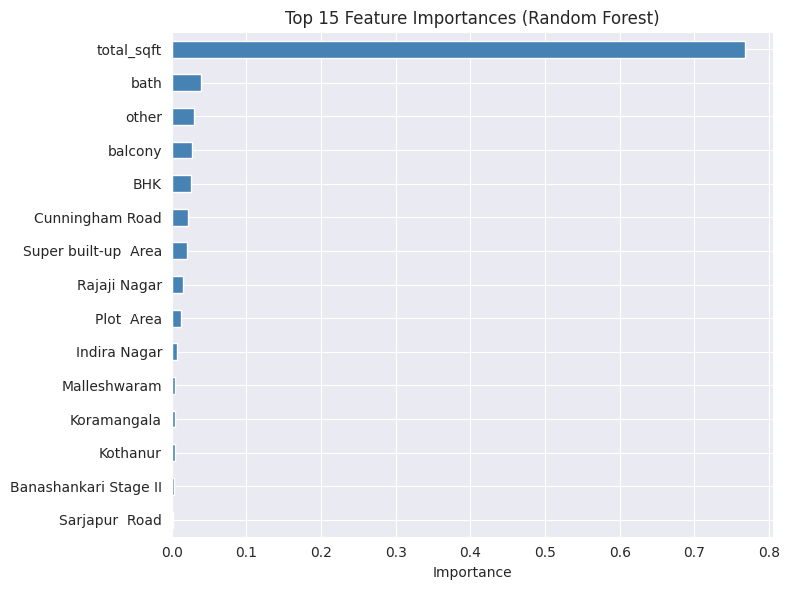

In [34]:
plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

###Model comparison bar chart

<Figure size 900x600 with 0 Axes>

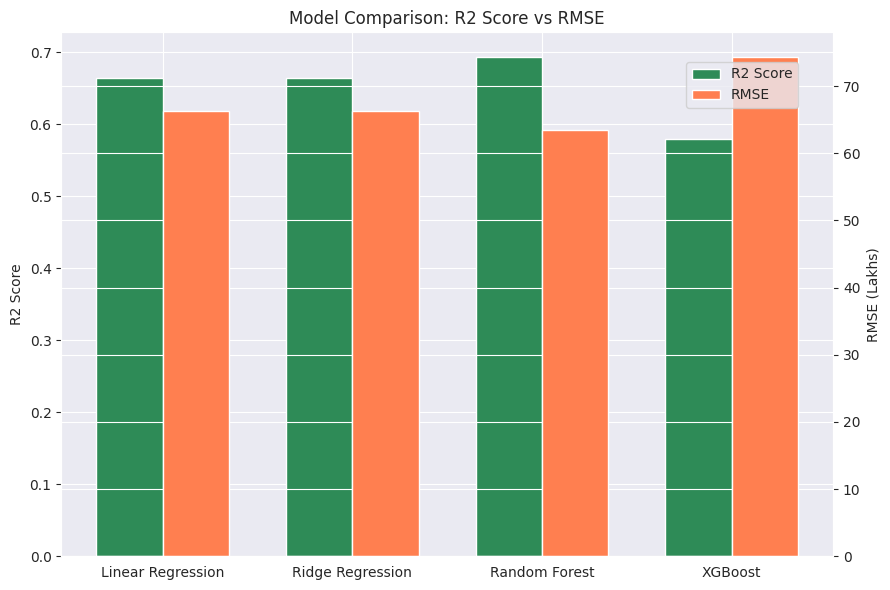

In [35]:
plt.figure(figsize=(9,6))
x = np.arange(len(results))
width = 0.35

fig, ax1 = plt.subplots(figsize=(9,6))
ax1.bar(x - width/2, results['R2 Score'], width, label='R2 Score', color='seagreen')
ax1.set_ylabel('R2 Score')
ax1.set_xticks(x)
ax1.set_xticklabels(results['Model'])
ax1.set_title('Model Comparison: R2 Score vs RMSE')

ax2 = ax1.twinx()
ax2.bar(x + width/2, results['RMSE'], width, label='RMSE', color='coral')
ax2.set_ylabel('RMSE (Lakhs)')

fig.legend(loc='upper right', bbox_to_anchor=(0.9,0.9))
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## Conclusion

This project reinforced that data cleaning, not model selection, is usually where the real work in a machine learning pipeline lives — nearly 20 steps went into cleaning inconsistent units, missing values, and outliers before any model was trained.

The final results also challenged a common assumption: XGBoost, often treated as a default "best" model, underperformed simpler linear models here due to the high-dimensional, sparse nature of one-hot encoded location features (180+ location dummy columns). Random Forest's ability to handle that sparsity through bagged, decorrelated trees made it the strongest choice for this dataset.

**Model Performance Summary:**
- Random Forest: R² = 0.69, MAE = ₹21.19L, RMSE = ₹63.45L (best)
- Ridge Regression: R² = 0.66, MAE = ₹24.11L, RMSE = ₹66.30L
- Linear Regression: R² = 0.66, MAE = ₹24.21L, RMSE = ₹66.32L
- XGBoost (tuned): R² = 0.58, MAE = ₹22.75L, RMSE = ₹74.30L

**Key Insight:** `total_sqft` alone drives ~77% of price prediction, confirming that square footage remains the dominant factor in Bengaluru real estate pricing, with bathroom count, BHK, and specific premium locations (Cunningham Road, Rajaji Nagar) contributing smaller but meaningful signal.

**Limitations & Future Work:**
- Model performs well for properties under ₹500 Lakhs but loses accuracy on ultra-luxury properties (₹2000+ Lakhs) due to their scarcity in training data
- Potential improvements: log-transforming the target variable (price distribution is right-skewed), adding richer location-level features (distance to city center, nearby amenities), and exploring non-linear feature interactions